# Experiment 5: NLP Pipeline with RNN/LSTM

**Student:** Yuvraj Gandhi &nbsp;|&nbsp; **Roll No:** 23101C0059 &nbsp;|&nbsp; **Branch:** INFT - C
**Subject:** Deep Learning Lab (PEIT37P) &nbsp;|&nbsp; **Dataset:** IMDB Movie Reviews

**Aim:** Build an end-to-end NLP pipeline for sentiment classification on the IMDB Movie Reviews
dataset, using text preprocessing (tokenization, padding), an Embedding + LSTM model, and
evaluation using precision, recall, and F1-score.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
Path("../models").mkdir(exist_ok=True)

tf.random.set_seed(42)
np.random.seed(42)

VOCAB_SIZE = 10000
MAX_LEN = 200

## Step 1 — Load the IMDB Dataset (fixed vocabulary size)

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

       0/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   32768/17464789 ━━━━━━━━━━━━━━━━━━━━ 33s 2us/step

   49152/17464789 ━━━━━━━━━━━━━━━━━━━━ 1:43 6us/step

   81920/17464789 ━━━━━━━━━━━━━━━━━━━━ 1:55 7us/step

  114688/17464789 ━━━━━━━━━━━━━━━━━━━━ 1:32 5us/step

...

15622144/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

16285696/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

16941056/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Training samples: 25000
Test samples: 25000


In [3]:
word_index = keras.datasets.imdb.get_word_index()
index_to_word = {i + 3: w for w, i in word_index.items()}
index_to_word[0], index_to_word[1], index_to_word[2] = "<pad>", "<start>", "<unk>"


def decode_review(sequence):
    return " ".join(index_to_word.get(i, "?") for i in sequence)


print("Label:", "Positive" if y_train[0] == 1 else "Negative")
print(decode_review(X_train[0])[:600], "...")

      0/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

 868352/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

1515520/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Label: Positive
<start> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <unk> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sa ...


### Review length distribution (motivates the padding length choice)

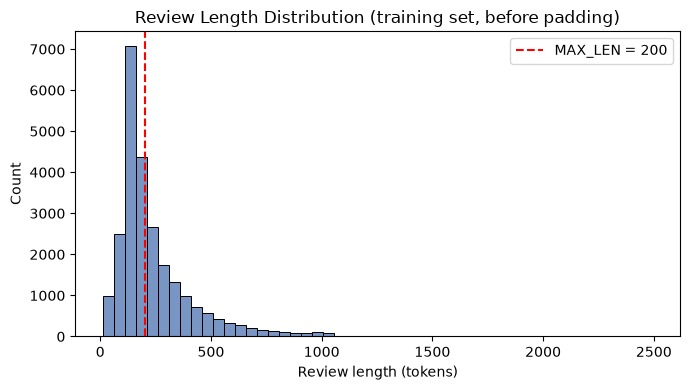

Median length: 178 | 90th pct: 467


In [4]:
lengths = [len(x) for x in X_train]

plt.figure(figsize=(7, 4))
sns.histplot(lengths, bins=50, color="#4C72B0")
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Review Length Distribution (training set, before padding)")
plt.xlabel("Review length (tokens)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "01_sequence_lengths.png", dpi=150)
plt.show()

print("Median length:", int(np.median(lengths)), "| 90th pct:", int(np.percentile(lengths, 90)))

## Step 2 — Pad / Truncate Sequences to a Fixed Length

In [5]:
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding="post", truncating="post")

print(X_train.shape)

(25000, 200)


## Step 3 & 4 — Build and Compile the Embedding + LSTM Model

In [6]:
model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,521 (5.08 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Train the Model

In [7]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    verbose=2,
)

Epoch 1/5


313/313 - 38s - 121ms/step - accuracy: 0.5306 - loss: 0.6916 - val_accuracy: 0.4988 - val_loss: 0.6936


Epoch 2/5


313/313 - 34s - 109ms/step - accuracy: 0.5494 - loss: 0.6734 - val_accuracy: 0.6080 - val_loss: 0.6391


Epoch 3/5


313/313 - 33s - 106ms/step - accuracy: 0.6510 - loss: 0.5974 - val_accuracy: 0.6450 - val_loss: 0.5923


Epoch 4/5


313/313 - 39s - 123ms/step - accuracy: 0.8124 - loss: 0.4375 - val_accuracy: 0.8310 - val_loss: 0.4349


Epoch 5/5


313/313 - 40s - 129ms/step - accuracy: 0.8828 - loss: 0.3177 - val_accuracy: 0.8526 - val_loss: 0.3761


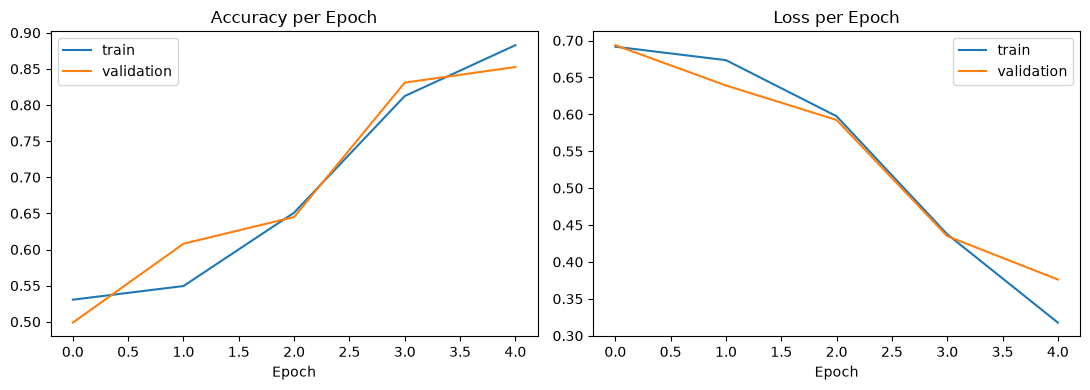

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "02_training_curves.png", dpi=150)
plt.show()

## Step 6 — Generate Predictions on the Test Set

In [9]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Overall test accuracy:", round(test_acc, 4))

  1/782 ━━━━━━━━━━━━━━━━━━━━ 3:28 267ms/step

  5/782 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step  

  8/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step

 11/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step

 14/782 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step

...

777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

779/782 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step


Overall test accuracy: 0.8311


## Step 7 — Evaluate: Precision, Recall, F1-Score, Confusion Matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Negative", "Positive"], output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("../results.csv")
print(cm)
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

[[10064  2436]
 [ 1787 10713]]
              precision    recall  f1-score   support

    Negative       0.85      0.81      0.83     12500
    Positive       0.81      0.86      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



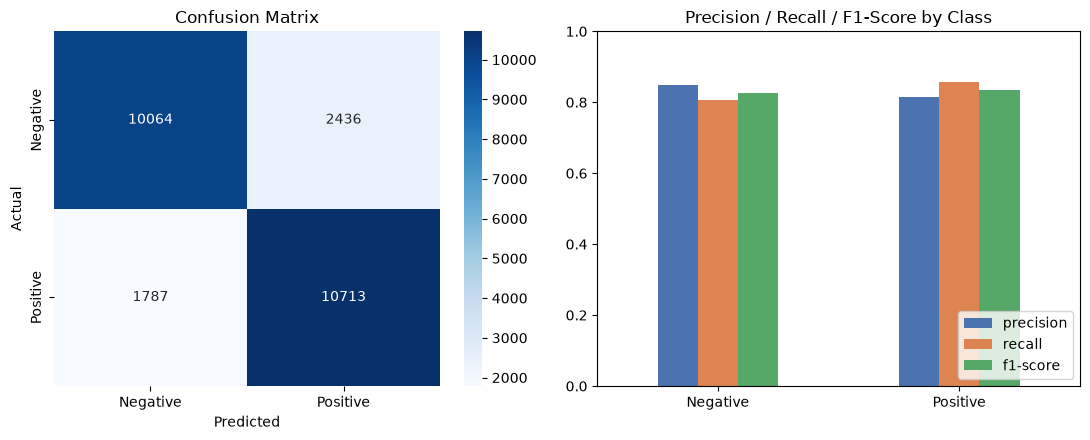

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

metrics_df = report_df.loc[["Negative", "Positive"], ["precision", "recall", "f1-score"]]
metrics_df.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Precision / Recall / F1-Score by Class")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", labelrotation=0)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES / "03_evaluation_metrics.png", dpi=150)
plt.show()

In [12]:
model.save("../models/imdb_lstm.h5")
print("Text preprocessed and padded")
print("Embedding + LSTM model trained")
print(f"Overall test accuracy: {test_acc * 100:.1f}%")
print("Evaluation metrics generated")

Text preprocessed and padded
Embedding + LSTM model trained
Overall test accuracy: 83.1%
Evaluation metrics generated


## Conclusion

An end-to-end NLP pipeline was built for sentiment classification on the IMDB dataset. Text was
tokenized (via Keras's built-in IMDB word-index encoding) and padded to a fixed length of 200
tokens, an Embedding-LSTM architecture was trained for 5 epochs, and the model was evaluated with
precision, recall, F1-score, and a confusion matrix (see `results.csv` and the plots above for
the measured figures from this run) — giving a fuller picture than accuracy alone and confirming
its suitability for deployment as a review-sentiment classifier.